# Knee Osteoarthritis Severity Detection (5 Classes)

This notebook trains a CNN to classify knee X-ray images into 5 severity grades of Osteoarthritis (Kellgren-Lawrence grading system):

| Class | Grade | Meaning |
|---|---|---|
| 0 | Healthy | No signs of osteoarthritis |
| 1 | Doubtful | Very early, uncertain signs |
| 2 | Minimal | Mild joint space narrowing |
| 3 | Moderate | Clear joint space narrowing, bone changes |
| 4 | Severe | Large loss of joint space, major bone changes |

**Dataset used:** [Knee Osteoarthritis Dataset with Severity Grading](https://www.kaggle.com/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity) (OAI - Osteoarthritis Initiative), organized on Kaggle as:
```
/kaggle/input/knee-osteoarthritis-dataset-with-severity/
    train/
        0/  1/  2/  3/  4/
    val/
        0/  1/  2/  3/  4/
    test/
        0/  1/  2/  3/  4/
```

This follows the same overall structure as the Brain Tumor Classification notebook (CNN + ImageDataGenerator + confusion matrix), with the addition of a simple **Grad-CAM explainability step** at the end.

In [1]:
import numpy as np
import pandas as pd
import os

# Input data files are available in the read-only "../input/" directory
input_dir = '/kaggle/input'
for root, dirs, files in os.walk(input_dir):
    print(f"Directory: {root}")
    for d in dirs[:5]:
        print(f"  Subdirectory: {d}")


Directory: /kaggle/input
  Subdirectory: datasets
Directory: /kaggle/input/datasets
  Subdirectory: shashwatwork
Directory: /kaggle/input/datasets/shashwatwork
  Subdirectory: knee-osteoarthritis-dataset-with-severity
Directory: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity
  Subdirectory: auto_test
  Subdirectory: val
  Subdirectory: test
  Subdirectory: train
Directory: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test
  Subdirectory: 2
  Subdirectory: 0
  Subdirectory: 3
  Subdirectory: 1
  Subdirectory: 4
Directory: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2
Directory: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/0
Directory: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/3
Directory: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/1
Directory: 

## 1. Data Loading & Augmentation

We use `ImageDataGenerator` to load images directly from the class-labeled folders (0-4) and apply augmentation (rotation, zoom, flips) so the model generalizes better on this relatively small medical dataset.

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Paths (update if your dataset folder name differs)
train_dir = '/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train'
val_dir   = '/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/val'
test_dir  = '/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/test'

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
num_classes = train_generator.num_classes
print("Number of classes:", num_classes)


Found 5778 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Class indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Number of classes: 5


## 2. Building the CNN Model

A standard Convolutional Neural Network: 3 convolution + pooling blocks to progressively learn edges → textures → joint-space patterns, followed by dense layers for the final 5-way classification.

In [10]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
base_model.trainable = False   # freeze pretrained layers initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,189 (27.85 MB)

 Trainable params: 263,685 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 3. Training the Model

In [11]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(0.5055118110236221), 1: np.float64(1.1047801147227534), 2: np.float64(0.7622691292875989), 3: np.float64(1.5265521796565389), 4: np.float64(6.679768786127168)}


In [12]:
EPOCHS = 25  

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weights_dict
)

model.save('/kaggle/working/knee_oa_severity_model.h5')
print("Model saved.")

Epoch 1/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 106s 448ms/step - accuracy: 0.2875 - loss: 1.5764 - val_accuracy: 0.3269 - val_loss: 1.3952
Epoch 2/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 41s 228ms/step - accuracy: 0.3472 - loss: 1.3346 - val_accuracy: 0.3523 - val_loss: 1.3095
Epoch 3/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 46s 251ms/step - accuracy: 0.3572 - loss: 1.2883 - val_accuracy: 0.2712 - val_loss: 1.2940
Epoch 4/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 41s 225ms/step - accuracy: 0.3723 - loss: 1.2750 - val_accuracy: 0.4395 - val_loss: 1.2956
Epoch 5/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 41s 227ms/step - accuracy: 0.3879 - loss: 1.2453 - val_accuracy: 0.4685 - val_loss: 1.2451
Epoch 6/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 40s 222ms/step - accuracy: 0.3915 - loss: 1.2291 - val_accuracy: 0.4346 - val_loss: 1.3150
Epoch 7/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 45s 248ms/step - accuracy: 0.3917 - loss: 1.2206 - val_accuracy: 0.5024 - val_loss: 1.2049
Epoch 8/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.4258 - loss: 

Model saved.


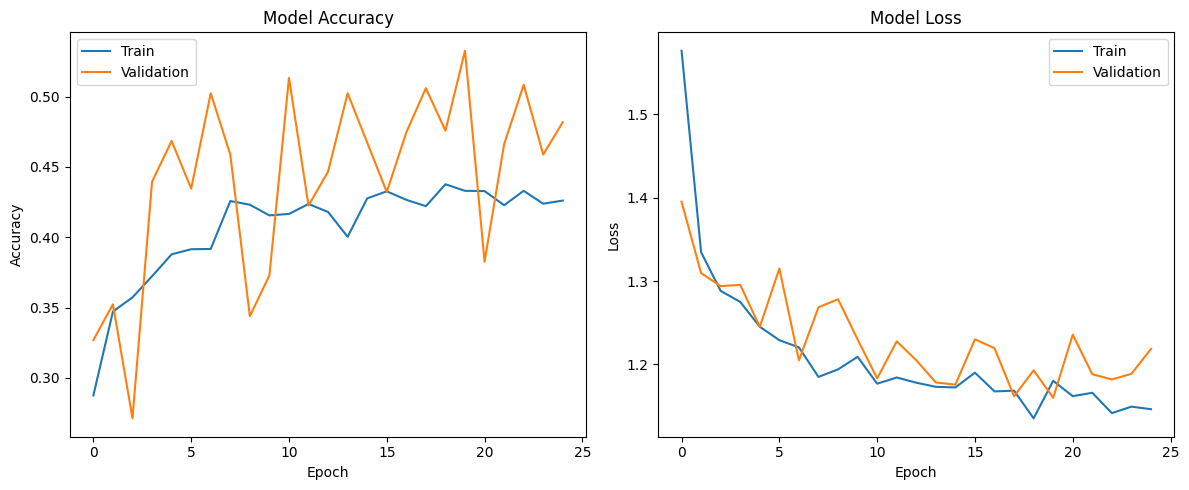

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()


## 4. Evaluation — Confusion Matrix & Classification Report

Because the classes (Healthy → Severe) are ordered and somewhat imbalanced (severe cases are rarer), a confusion matrix is especially useful to see if the model confuses **neighbouring severity grades** (e.g. Moderate vs Severe) rather than distant ones (e.g. Healthy vs Severe), which is the typical real-world error pattern for this problem.

52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 376ms/step


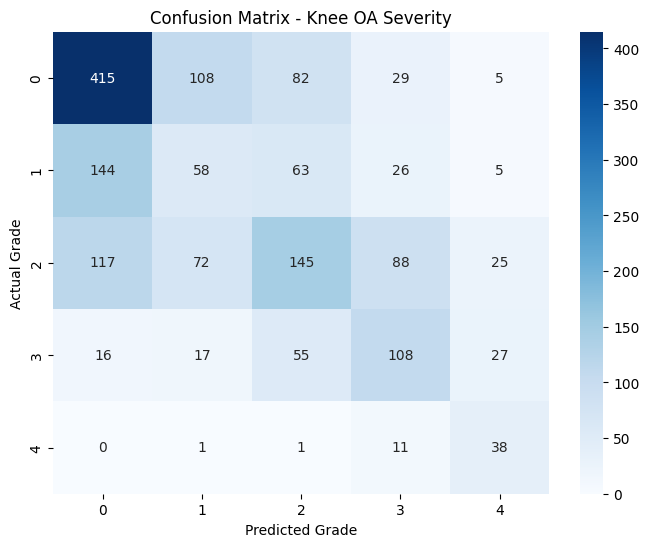

              precision    recall  f1-score   support

           0       0.60      0.65      0.62       639
           1       0.23      0.20      0.21       296
           2       0.42      0.32      0.37       447
           3       0.41      0.48      0.45       223
           4       0.38      0.75      0.50        51

    accuracy                           0.46      1656
   macro avg       0.41      0.48      0.43      1656
weighted avg       0.45      0.46      0.45      1656



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_generator.reset()
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_labels = list(train_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Grade'); plt.ylabel('Actual Grade')
plt.title('Confusion Matrix - Knee OA Severity')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))


## 5. Predicting on a New X-ray Image

In [15]:
from tensorflow.keras.preprocessing import image

severity_labels = {
    0: 'Healthy',
    1: 'Doubtful',
    2: 'Minimal',
    3: 'Moderate',
    4: 'Severe'
}

def predict_knee_oa_severity(img_path, model=model):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    predicted_class = np.argmax(preds, axis=1)[0]

    print(f"Predicted Severity: {severity_labels[predicted_class]} (Grade {predicted_class})")
    print(f"Confidence scores: {dict(zip(severity_labels.values(), np.round(preds[0], 3)))}")
    return predicted_class, preds

# Example usage:
predict_knee_oa_severity('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/test/3/9055836L.png')


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted Severity: Minimal (Grade 2)
Confidence scores: {'Healthy': np.float32(0.249), 'Doubtful': np.float32(0.295), 'Minimal': np.float32(0.304), 'Moderate': np.float32(0.149), 'Severe': np.float32(0.003)}


(np.int64(2),
 array([[0.24852765, 0.29498133, 0.30400747, 0.14909548, 0.00338802]],
       dtype=float32))